# Optimal transfer learning

Here, we create two models and traverse a path on the statistical manifold between them.
Given my theory's optimal infinitesimal traversals of continuously changing distributions, 
the theory should port cleanly from reinforcement learning to transfer learning. 
Of course, only each infinitesimal step along the path with be optimal, 
leaving room for data scientists' intuition to usefully bias retention. 
For example, if early game information only becomes useful late in play, 
then a retention spike will need to be added. 
Regardless, infinitesimal optimality is an important step toward a deep and coherent transfer learning theory. 

The experiment will involve fitting a dense net to the MNIST dataset, classifying digits as usual. 
However, after the initial fit, we will embed the dense net into a much larger statistical manifold 
by making it part of a mixture model with a different, far more sparse model. 
We'll then slowly and continuously traverse the mixture probability parameter $q$ from 0 to 1, 
optimally retaining information at each step. 
We'll measure test set accuracy at each step and compare against different traversal strategies. 
A good result should find accuracy is optimally and usefully sustained despite transferring to a sparse model.

If successful, this experiment will illustrate the effectiveness of my general theory of transfer learning. 
Thus, it'd be possible to optimally translate information optimally between arbitrary models, 
provided they can handle the same dataset or a continuously transforming dataset between the models.
This is a powerful result, so I'm eager to run my experiment, but won't get my hopes up too much. 
The truth is best found by the pursuit of ambitious targets and sensitively understanding negative results.

In [1]:
## Dense net code initially authored by Google's search engine GenAI on 20 Oct 2024. 
## I've applied minor modifications for generality, but the code worked great on first draft. 

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Define the DenseNet model
class DenseNet(nn.Module):
    def __init__(self):
        super(DenseNet, self).__init__()
        self.features = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        if x.shape[0] == 0: 
            return torch.tensor([])
        x = x.view(x.size(0), -1)
        x = self.features(x)
        return x

# Load MNIST dataset
train_dataset = datasets.MNIST(root='/tmp/data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='/tmp/data', train=False, transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

Failed to download (trying next):
HTTP Error 403: Forbidden

Extracting /tmp/data/MNIST/raw/train-images-idx3-ubyte.gz to /tmp/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden

Extracting /tmp/data/MNIST/raw/train-labels-idx1-ubyte.gz to /tmp/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden

Extracting /tmp/data/MNIST/raw/t10k-images-idx3-ubyte.gz to /tmp/data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden

Extracting /tmp/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /tmp/data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 2026652.00it/s]


In [2]:
## Dense net experiment, needs about 1-2 min of compute 

# Initialize the model, loss function and optimizer
model = DenseNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 5
for epoch in range(num_epochs):
    for i, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, i+1, len(train_loader), loss.item()))

# Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print('Accuracy of the network on the 10000 test images: {} %'.format(100 * correct / total))

/anaconda/envs/azureml_py38/lib/python3.8/site-packages/torch/autograd/graph.py:769: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [1/5], Step [1/938], Loss: 2.3135
Epoch [1/5], Step [101/938], Loss: 0.4268
Epoch [1/5], Step [201/938], Loss: 0.2668
Epoch [1/5], Step [301/938], Loss: 0.2492
Epoch [1/5], Step [401/938], Loss: 0.1270
Epoch [1/5], Step [501/938], Loss: 0.0292
Epoch [1/5], Step [601/938], Loss: 0.0870
Epoch [1/5], Step [701/938], Loss: 0.0372
Epoch [1/5], Step [801/938], Loss: 0.0698
Epoch [1/5], Step [901/938], Loss: 0.1002
Epoch [2/5], Step [1/938], Loss: 0.2562
Epoch [2/5], Step [101/938], Loss: 0.0947
Epoch [2/5], Step [201/938], Loss: 0.0100
Epoch [2/5], Step [301/938], Loss: 0.2967
Epoch [2/5], Step [401/938], Loss: 0.0622
Epoch [2/5], Step [501/938], Loss: 0.0788
Epoch [2/5], Step [601/938], Loss: 0.1078
Epoch [2/5], Step [701/938], Loss: 0.0821
Epoch [2/5], Step [801/938], Loss: 0.1264
Epoch [2/5], Step [901/938], Loss: 0.0517
Epoch [3/5], Step [1/938], Loss: 0.0079
Epoch [3/5], Step [101/938], Loss: 0.1816
Epoch [3/5], Step [201/938], Loss: 0.0847
Epoch [3/5], Step [301/938], Loss: 0.032

In [11]:
## Models for transfer learning to sparse nets 
from ssr_agent import SSRAgent 
from replay_buffer import ReplayBuffer 
from torch.nn import functional as F 

class PartiallySparseLinear(nn.Module):
    def __init__(self, in_dim, out_dim_1, out_dim_2, dropout_p=0.): 
        '''Output dim is `out_dim_1 + out_dim_2`, but last `out_dim_2` dimensions are subjected to dropout. 
        This is useful for diffeomorphically traversing to more or less dimensions, 
        and thus facilitating differentially optimal transfer learning. 
        ''' 
        super(PartiallySparseLinear, self).__init__()
        self.in_dim = in_dim 
        self.out_dim_1 = out_dim_1 
        self.out_dim_2 = out_dim_2 
        self.linear = nn.Linear(in_dim, out_dim_1 + out_dim_2) ## handles initialization 
        self.dropout = nn.Dropout(p=dropout_p) 
        pass 
    def set_p(self, p): 
        self.dropout.p = p 
        pass 
    def forward(self, x): 
        w = self.linear.weight * 1. ## parameters don't have `copy` 
        w[:,self.out_dim_1:self.out_dim_2] = self.dropout(w[:,self.out_dim_1:self.out_dim_2]) 
        return F.linear(x, w, self.linear.bias) 
    pass 

class SparseActivation(nn.Module): 
    '''Softmax that zeros-out small values. 
    Transfer-learning from a prefit model recommended. 
    ''' 
    def __init__(self, K=1, next_linearity=None): 
        'K: determines maximum number of non-zero dimensions.' 
        super(SparseActivation, self).__init__()
        self.K = K 
        self.softmax = nn.Softmax(dim=1) 
        self.relu = nn.ReLU() 
        self.next_linearity = next_linearity 
        pass 
    def forward(self, x, next_linearity=None): 
        '''inputs:
        - x: [n, ...]-shaped tensor 
        - next_linearity: instance of nn.Linear is applied efficiently to output of this activation. Autodetects next_nonlinearity if it was provided during init. 
        ouputs: 
        - idx: indicies of softmax(x) that are greater than 1/K. 
        - softmax(x)[idx]: values of softmax(x) that are greater than 1/K. 
        '''
        ## get next_linearity 
        #if next_linearity is None and self.next_linearity is None: 
        #    return idx, x_idx 
        if next_linearity is None and self.next_linearity is not None: 
            next_linearity = self.next_linearity 
            pass 
        ## calculate 
        idx = (self.softmax(x) >= 1/self.K).nonzero(as_tuple=True) 
        y = torch.zeros(x.shape) 
        y[idx] = self.relu(x[idx])  
        return next_linearity(y) 
        #x[idx] = 0. ## breaks differentiation 
        ## TODO use a sparsity library 
        return next_linearity(x) 
        #x_idx = x[idx] ## TODO minimize multiplications by zero !!! Avoided to test efficiency 
        #if next_linearity is None and self.next_linearity is None: 
        #    return idx, x_idx 
        #if next_linearity is None and self.next_linearity is not None: 
        #    next_linearity = self.next_linearity 
        #    pass 
        ### efficiently apply next_linearity 
        #if x_idx.shape[0] > 0: 
        #    ## x cols correspond to weight rows 
        #    y = x_idx.matmul(next_linearity.weight[idx[1],:]) 
        #else: 
        #    y = torch.zeros([0, next_linearity.bias.shape[0]]) 
        #    pass 
        #y += next_linearity.bias 
        #return y.reshape([x.shape[0], -1]) 
    pass 

class SparseNet(nn.Module): 
    def __init__(self, K=10): 
        super(SparseNet, self).__init__() 
        self.K = K 
        #self.linear1 = nn.Linear(784, 512) 
        #self.linear2 = nn.Linear(512, 256) 
        #self.linear3 = nn.Linear(256, 128) 
        self.linear4 = nn.Linear(128, 10) 
        self.pslinear1 = PartiallySparseLinear(784, 64, 512-64) 
        self.pslinear2 = PartiallySparseLinear(512, 64, 256-64) 
        self.pslinear3 = PartiallySparseLinear(256, 64, 128-64) 
        #self.pslinear4 = PartiallySparseLinear(128, 64, 64-64) 
        self.activation1 = SparseActivation(K=self.K, next_linearity=self.pslinear2) 
        self.activation2 = SparseActivation(K=self.K, next_linearity=self.pslinear3) 
        self.activation3 = SparseActivation(K=self.K, next_linearity=self.linear4) 
        #self.activation4 = nn.Softmax(dim=1) 
        pass 
    def forward(self, x): 
        if x.shape[0] == 0: 
            return torch.tensor([]) 
        x = x.view(x.size(0), -1) 
        x = self.activation1(self.pslinear1(x)) 
        x = self.activation2(x) 
        x = self.activation3(x) 
        #x = self.activation4(x) 
        return x 
    def set_K(self, K): 
        self.activation1.K = K 
        self.activation2.K = K 
        self.activation3.K = K 
        pass 
    def set_dropout_p(self, p): 
        self.pslinear1.set_p(p) 
        self.pslinear2.set_p(p) 
        self.pslinear3.set_p(p) 
        pass 
    pass 

class MixtureModel(nn.Module): 
    'join two models with a Bernoulli random variable'
    def __init__(self, model1, model2, p): 
        'mix models 1 and 2, selecting model 2 with probability p'
        super(MixtureModel, self).__init__() 
        self.model1 = model1 
        self.model2 = model2 
        self.p = p 
        pass 
    def forward(self, x): 
        n = x.shape[0] 
        if n == 0: 
            return torch.tensor([]) 
        b = torch.rand(n) <= self.p 
        b_sum = b.sum() 
        y = torch.zeros([n,10]) 
        if b_sum < n: 
            y[b.logical_not(),:] = self.model1(x[b.logical_not(),:]) 
        if b_sum > 0: 
            y[b,:] = self.model2(x[b,:]) 
            pass 
        return y 
    pass 

class Model(SSRAgent): 
    'Run transfer learning experiments with this model' 
    def __init__(self, p, K=10, ssr_rank=5, replay_buffer=None): 
        'p: probability of the mixture model selecting the sparse model' 
        if replay_buffer is None: 
            replay_buffer = ReplayBuffer() 
            pass 
        super(Model, self).__init__(replay_buffer=replay_buffer, ssr_rank=ssr_rank) 
        ## register sub-models as attributes so they initialize 
        self.model1 = DenseNet() 
        self.model2 = SparseNet(K=K) 
        ## register with mixture model 
        self.mixture_model = MixtureModel( 
            model1 = self.model1, 
            model2 = self.model2, 
            p=p 
        ) 
        self.criterion = nn.CrossEntropyLoss() 
        self.optimizer = optim.Adam(self.parameters(), lr=0.001) 
        pass 
    def loss(self, data): 
        y_hat = self.mixture_model(data.x) 
        return self.criterion(y_hat, data.y) 
    def fit_iters(self, n_iters=100, batch_size=256, pi_min=.1, pi_max=.9): 
        self.train() 
        pi = self.optimal_lambda(pi_min=pi_min, pi_max=pi_max) 
        for _ in range(n_iters): 
            self.optimizer.zero_grad() 
            data = self.replay_buffer.sample(batch_size=batch_size) 
            loss = pi * self.loss(data) + (1 - pi) * self.ssr() 
            l = float(loss) 
            loss.backward() 
            self.optimizer.step() 
            pass 
        return pi, l  
    def forward(self, x):
        return self.mixture_model(x) 
    def test_acc(self): 
        self.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in test_loader:
                #print(f'DEBUG 1: x.shape: {x.shape}, y.shape: {y.shape}')
                output = self(x)
                _, y_hat = torch.max(output.data, 1)
                total += y.size(0)
                correct += (y_hat == y).sum().item() 
                pass 
            pass 
        return correct / total 
    pass 


In [4]:
## heavier compute starts here 
## this block needs 30 seconds 

replay_buffer = ReplayBuffer() 
## load data 
for x, y in train_loader: 
    x = x.reshape([x.shape[0], -1])
    replay_buffer.add(x=x, y=y) 
    pass 

In [12]:
from tqdm import tqdm 

N = 100 ## number of path steps over p 

model = Model(p=1., K=100, replay_buffer=replay_buffer) 

## traverse p 
acc = [] 
pi = [] 
loss = [] 
tq = tqdm(range(N+1)) 
for i in tq: 
    #model.mixture_model.p = i/N 
    model.mixture_model.model2.set_K( 784 * (1 - i/N) + 50 * (i/N) ) 
    model.mixture_model.model2.set_dropout_p( i/N ) 
    n_iters = 1000 if i == 0 else 100 
    p, l = model.fit_iters(n_iters=n_iters, pi_min=0.001) 
    a = model.test_acc() 
    model.memorize(n=100, random_idx=True) 
    acc.append(a) 
    pi.append(p) 
    loss.append(l) 
    tq.set_description(f'acc: {round(float(a),3)}, pi: {round(float(p), 5)}, loss: {round(float(l), 3)}') 
    pass 

acc: 0.705, pi: 0.9, loss: 0.849: 100%|██████████| 101/101 [24:51<00:00, 14.77s/it]


Experimental observations:

1. Attempting a mixture model between a dense and sparse model, traversing $p$ from dense to sparse, has completely failed. 
$\hat \pi$ diverged to zero, likely because the dense model was near a solution point while the sparse model was not, 
the invalidating PSD Hessian assumption. 
2. Learning from experiment 1, I'll now keep $p=1$ constant, and instead traverse $K$ from large to small, thereby taking a dense model and continuously transforming it toward sparsity. Observation: at $K \approx \infty$, accuracy was 20% (later climbing to 27%), so the softmax activation is performing terribly. 
3. Keeping the softmax to enact sparsity but passing-forward with relu activations entirely resolved the low accuracy issue, achieving 86%. It's not time to try and prove optimality through correct selection of $\pi$. So far, $\hat \pi$ has always hit .1 through a lower bound. I'll reduce that lower bound to allow it to take more-optimal values.
4. I found a bug in my $\hat \pi$ code and resolved it. It now hovers at its maximum (.9) with accuracy hanging around 86%. I'd like to eventually evaluate 
   - the effect of tuning step sizes to achieve better $\hat \pi$ values, perhaps targeting .5, 
   - and the effectiveness of continuously reducing dimensionality. 
5. I've used dropout to continuously reduce dimensionality, taking $p$ from 0 to 1. It works well, but accuracy drops-off quickly after $p$ passes .9, .95 or so. While $\hat \pi$ stayed high the whole time, I'm curious if more accuracy can be maintained by dynamically adjusting step sizes to keep $\hat \pi$ near .5.

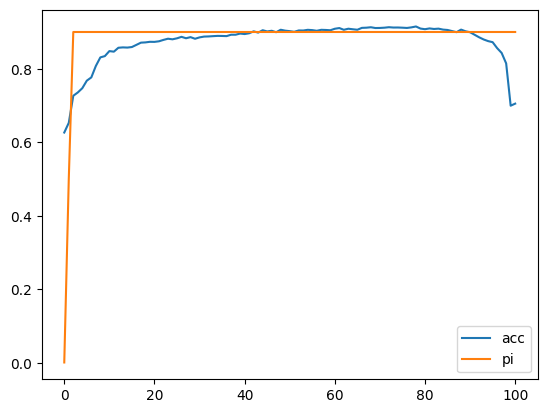

In [13]:
## plot accuracy and pi  
import matplotlib.pyplot as plt 

plt.plot(acc, label='acc') 
plt.plot(pi, label='pi') 
plt.legend() 
plt.show() 

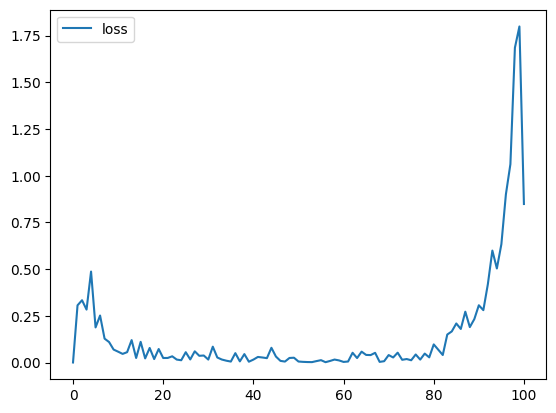

In [14]:
## plot loss 
plt.plot(loss, label='loss')
plt.legend() 
plt.show() 

In [15]:
## inspect tensor execution graphs 

print(f'model.p: {model.mixture_model.p}') 
t = replay_buffer.sample(1)
y_hat = model(t.x)
#print(y_hat.grad_fn.next_functions[1][0].next_functions[0][0]) 

def print_execution_graph(t_grad_fn, i=0):
    for f in t_grad_fn.next_functions: 
        f = f[0] 
        if f is not None: 
            print(f'{" "*i} {str(f)}') 
            print_execution_graph(f, i=i+1)
            pass
        pass
    pass 

print_execution_graph(y_hat.grad_fn)

model.p: 1.0
